# Import all the necessary libraries and frameworks

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score
)
import shap
import joblib
import os

### Set up file paths and create output directories
- Define input path for dataset and output directories for models, metrics, SHAP values, and feature importances.
- Use `os.makedirs(..., exist_ok=True)` to create folders only if they don’t already exist.


In [150]:
DATA_PATH = "../data/datasets/panel_dataset_VIF_normalized.xlsx"
MODEL_DIR = "../models"
IMPORTANCE_DIR = "../data/feature_importance"
SHAP_DIR = "../data/shap_values"
METRICS_DIR = "../data/model_performance/per_country"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(IMPORTANCE_DIR, exist_ok=True)
os.makedirs(SHAP_DIR, exist_ok=True)

### Initial setup
- `DROP_COLS`: list of columns to exclude from training (e.g., date and country).
- `RANDOM_STATE`: ensures reproducibility when training models.
- `TEST_SIZE`: the fraction of data to be set aside for testing.

In [151]:
DROP_COLS = ['date', 'Country']
RANDOM_STATE = 42
TEST_SIZE = 0.2

### Load and prepare dataset
- Load the VIF-normalized panel dataset from Excel.
- Convert `date` to datetime format and sort the data by `Country` and `date`.

In [152]:
df = pd.read_excel(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
# Results
all_results = []

### Cut off date

In [153]:
train_start = "1995-01-01"
train_end = "2009-12-31"
val_end = "2018-12-31"
test_end = "2024-05-31"

### Picking the target

In [188]:
target = "RECESS"

### Define feature and target sets
- `X`: feature matrix after dropping `date`, `Country`, and target columns.
- `y`: binary classification target (e.g., RECESS, RECESS_OVER, etc.).


In [ ]:
# Drop non-feature columns (drop all targets + drop_cols)
X = df.drop(columns=DROP_COLS + [target])
y = df[target]

### Create time-based masks
- Use the `date` column to create boolean masks for each dataset split:
  - `train_mask`: includes rows between `train_start` and `train_end`.
  - `val_mask`: includes rows between `train_end` and `val_end`.
  - `test_mask`: includes rows between `val_end` and `test_end`.


In [189]:
# Filter each split based on the 'date' column
train_mask = (df['date'] >= train_start) & (df['date'] <= train_end)
val_mask   = (df['date'] > train_end) & (df['date'] <= val_end)
test_mask  = (df['date'] > val_end) & (df['date'] <= test_end)

### Apply time-based splits to features and labels
- Subset the feature matrix `X` and target vector `y` using the masks:
  - `X_train`, `y_train`: training data.
  - `X_val`, `y_val`: validation data.
  - `X_test`, `y_test`: test data.

In [190]:
X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

### Visualizing splits

In [191]:
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

print(f"Train Date Range: {df[train_mask]['date'].min().date()} to {df[train_mask]['date'].max().date()}")
print(f"Validation Date Range: {df[val_mask]['date'].min().date()} to {df[val_mask]['date'].max().date()}")
print(f"Test Date Range: {df[test_mask]['date'].min().date()} to {df[test_mask]['date'].max().date()}")


Train: 1080 samples
Validation: 648 samples
Test: 390 samples
Train Date Range: 1995-01-01 to 2009-12-01
Validation Date Range: 2010-01-01 to 2018-12-01
Test Date Range: 2019-01-01 to 2024-05-01


### Creating the model

In [192]:
model = XGBClassifier(
    n_estimators=100,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    use_label_encoder=False
)

### Training the model
- Instantiate and fit an XGBoost model on the training data.
- Use `scale_pos_weight` to handle class imbalance.


In [193]:
model.fit(X_train, y_train)

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [06:30:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

### Validating the model

In [194]:
y_prob = model.predict_proba(X_test)[:, 1]

best_thresh = 0.5
best_f1 = 0

### Fine tuning for the testing data

In [195]:
for t in np.arange(0.1, 0.9, 0.01):
    y_pred = (y_prob > t).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

### Evaluate model performance
- Calculate AUC, F1, Precision, Recall, and Accuracy metrics on the test set.

In [196]:
y_pred_final = (y_prob > best_thresh).astype(int)

auc = roc_auc_score(y_test, y_prob)
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
accuracy = accuracy_score(y_test, y_pred_final)

In [197]:
print(f"[TUNE] Best Threshold = {best_thresh:.2f}")
print(f"[EVAL] AUC = {auc:.3f}, Accuracy = {accuracy:.3f}, F1 = {best_f1:.3f}, Precision = {precision:.3f}, Recall = {recall:.3f}")

[TUNE] Best Threshold = 0.42
[EVAL] AUC = 0.635, Accuracy = 0.508, F1 = 0.495, Precision = 0.338, Recall = 0.922


### Record evaluation results
- Append the current model's performance to a results list.
- Convert to DataFrame for easier viewing or saving.


In [198]:
all_results.append({
    "Target": target,
    "AUC": auc,
    "F1": best_f1,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy,
    "Threshold": best_thresh
})

In [199]:
results_df = pd.DataFrame(all_results)
results_df

,Target,AUC,F1,Precision,Recall,Accuracy,Threshold
0,RECESS_PERIOD,0.860893,0.675159,0.841270,0.563830,0.869231,0.19
1,RECESS_OVER,0.943786,0.709677,0.666667,0.758621,0.953846,0.76
2,RECESS,0.635212,0.494737,0.338129,0.921569,0.507692,0.42


### Export evaluation results
- Save the full evaluation summary to a CSV file.


In [187]:
results_path = f"{METRICS_DIR}/XGB_per_country_email_results.csv"
results_df.to_csv(results_path, index=False)

print(f"[INFO] Results saved to: {results_path}")

[INFO] Results saved to: ../data/model_performance/per_country/XGB_per_country_email_results.csv


### Feature importance
- Extract and rank features by importance.
- Export results to a CSV file for analysis or SHAP comparison.


In [167]:
importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

importance_path = os.path.join(IMPORTANCE_DIR, f"XGB_{target}_importance.csv")
importances.to_csv(importance_path)

print(f"[INFO] Feature importance saved: {importance_path}")

[INFO] Feature importance saved: ../data/feature_importance\XGB_RECESS_PERIOD_importance.csv


### Compute SHAP values
- Use `shap.Explainer()` to create a model-agnostic explainer from the trained XGBoost model.
- Compute SHAP values for each instance in the training set to understand how each feature contributes to the predictions.


In [168]:
explainer = shap.Explainer(model)
shap_values = explainer(X_train)

### Aggregate SHAP values
- Convert the SHAP values into a DataFrame for easier analysis.
- Take the absolute value of SHAP values and compute the mean across all rows.
- Sort the features by their average impact on model predictions in descending order.

In [169]:
shap_df = pd.DataFrame(shap_values.values, columns=X_train.columns)
mean_shap = shap_df.abs().mean().sort_values(ascending=False)

### Save SHAP summary to CSV
- Save the mean absolute SHAP values to a CSV file in the designated SHAP directory.
- This file can be used for reporting or visualization later.


In [170]:
shap_path = os.path.join(SHAP_DIR, f"XGB_SHAP_{target}.csv")
mean_shap.to_csv(shap_path)

print(f"INFO. SHAP values saved: {shap_path}")

INFO. SHAP values saved: ../data/shap_values\XGB_SHAP_RECESS_PERIOD.csv


### Plot the top 20 features
- Generate a summary bar plot showing the most impactful features.


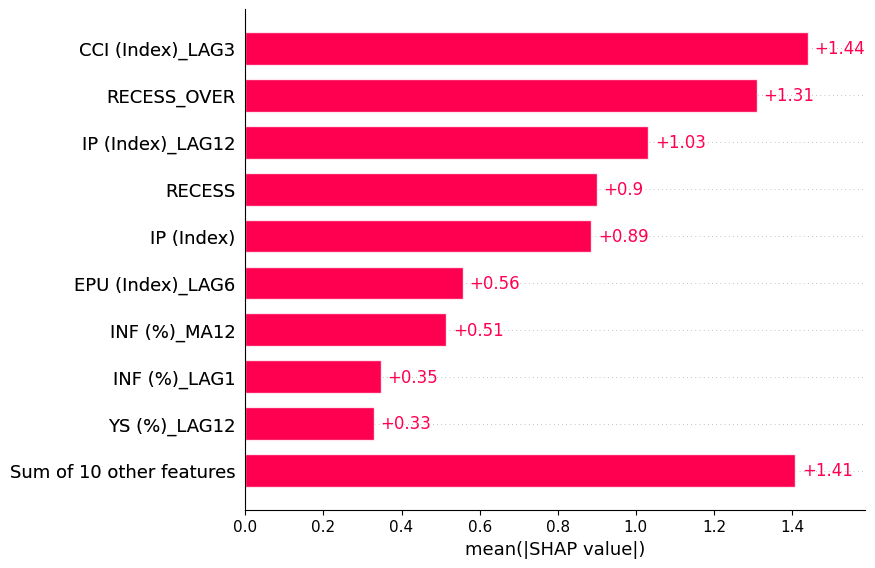

In [171]:
shap.plots.bar(shap_values[:, :20], show=True)

### Save the plot


In [172]:
shap_plot_path = os.path.join(SHAP_DIR, f"XGB_SHAP_barplot_{target}.png")
plt.savefig(shap_plot_path, bbox_inches='tight', dpi=300)
plt.close()

print(f"[INFO] SHAP bar plot saved: {shap_plot_path}")

[INFO] SHAP bar plot saved: ../data/shap_values\XGB_SHAP_barplot_RECESS_PERIOD.png


### Save the trained model
- Store the fitted XGBoost model as a `.pkl` file for later reuse or deployment.

In [173]:
model_path = os.path.join(MODEL_DIR, f"XGB_model_{target}.pkl")
joblib.dump(model, model_path)

print(f"[INFO] Model saved: {model_path}")

[INFO] Model saved: ../models\XGB_model_RECESS_PERIOD.pkl
